# NBA Player Clustering
This is the accompanying code for the medium article *Identifying NBA player similarity with Machine Learning*

Please download the **"2025 data final.csv"** to properly run this **code**

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn scipy adjustText

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from scipy.spatial import ConvexHull

try:
  from google.colab.data_table import DataTable
  DataTable.max_columns = 40
except:
  pass

from adjustText import adjust_text


The steps taken in the Data Collection and Cleaning section are stored in "2025 data final.csv" so you can skip that section and simply load the .csv below!

In [52]:
data = pd.read_csv("2025 data final.csv").set_index("Player")
data.head()

,PTS,AST,ORB,DRB,STL,BLK,TOV,FGA,3PA,FTA,...,DBPM,0-3 % of FGA,10-16 % of FGA,3P % of FGA,0-3 FG%,10-16 FG%,% of 2P Ast’d,% of 3P Ast’d,Dunks %FGA,3PA% Corner
Player,,,,,,,,,,,,,,,,,,,,,
Mikal Bridges,23.6,5.0,1.2,3.1,1.2,0.7,2.2,19.3,7.6,1.9,...,-0.9,0.185,0.192,0.391,0.785,0.507,0.682,0.957,0.025,0.449
Josh Hart,18.0,7.8,2.8,9.9,2.0,0.5,2.7,13.2,4.3,3.5,...,1.8,0.408,0.066,0.327,0.732,0.412,0.613,0.869,0.030,0.258
Anthony Edwards,37.4,6.2,1.0,6.7,1.6,0.9,4.3,27.7,13.9,8.5,...,0.0,0.176,0.084,0.503,0.678,0.341,0.384,0.475,0.039,0.107
Devin Booker,34.0,9.4,1.3,4.1,1.2,0.3,3.9,25.1,9.7,8.5,...,-2.4,0.109,0.206,0.388,0.690,0.531,0.431,0.716,0.013,0.123
James Harden,31.8,12.1,1.0,7.1,2.1,1.0,6.0,22.9,11.8,10.2,...,0.8,0.106,0.122,0.516,0.657,0.405,0.176,0.370,0.003,0.042


# Data Collection and Cleaning

Since this project only uses one season, I manually downloaded the three Basketball Reference pages.

This section combines them, drops duplicates, and filters out irrelevant players.

Again, you can skip this by loading in the "2025 data final.csv" file

In [27]:
def load_and_process(filepath, cols):
    df = pd.read_csv(filepath)

    #Filter out duplicate players who got traded
    player_counts = df["Player"].value_counts()
    traded_players = player_counts[player_counts > 1].index
    single_team_rows = df[~df["Player"].isin(traded_players)]
    combined_rows = df[(df["Player"].isin(traded_players)) & (df["Team"].str.contains("TM"))]
    filtered = pd.concat([single_team_rows, combined_rows], ignore_index=True)

    #Set index to player names
    filtered = filtered[cols].set_index("Player").drop("Team", axis = 1)
    return filtered

In [28]:
#Columns to use
per100_cols = ["Player", "Team", "PTS", "AST", "ORB", "DRB", "STL", "BLK", "TOV", "FGA", "3PA", "FTA", "eFG%", "FG%", "3P%", "FT%", "G", "MP"]
advanced_cols = ["Player", "Team", "TS%", "USG%", "AST%", "ORB%", "DRB%", "STL%", "BLK%", "TOV%","3PAr", "FTr", "OBPM", "DBPM"]
shooting_cols = ["Player", "Team", "0-3 % of FGA", "10-16 % of FGA", "3P % of FGA", "0-3 FG%", "10-16 FG%", "% of 2P Ast’d", "% of 3P Ast’d", "Dunks %FGA", "3PA% Corner"]

#Load and process each csv
per100 = load_and_process("datasets/b-ref per100.csv", per100_cols)
advanced = load_and_process("datasets/b-ref advanced.csv", advanced_cols)
shooting = load_and_process("datasets/b-ref shooting.csv", shooting_cols)

#Combine by Player name
data = pd.concat([per100, advanced, shooting], axis=1, join='inner')
data.head()

,PTS,AST,ORB,DRB,STL,BLK,TOV,FGA,3PA,FTA,...,DBPM,0-3 % of FGA,10-16 % of FGA,3P % of FGA,0-3 FG%,10-16 FG%,% of 2P Ast’d,% of 3P Ast’d,Dunks %FGA,3PA% Corner
Player,,,,,,,,,,,,,,,,,,,,,
Mikal Bridges,23.6,5.0,1.2,3.1,1.2,0.7,2.2,19.3,7.6,1.9,...,-0.9,0.185,0.192,0.391,0.785,0.507,0.682,0.957,0.025,0.449
Josh Hart,18.0,7.8,2.8,9.9,2.0,0.5,2.7,13.2,4.3,3.5,...,1.8,0.408,0.066,0.327,0.732,0.412,0.613,0.869,0.030,0.258
Anthony Edwards,37.4,6.2,1.0,6.7,1.6,0.9,4.3,27.7,13.9,8.5,...,0.0,0.176,0.084,0.503,0.678,0.341,0.384,0.475,0.039,0.107
Devin Booker,34.0,9.4,1.3,4.1,1.2,0.3,3.9,25.1,9.7,8.5,...,-2.4,0.109,0.206,0.388,0.690,0.531,0.431,0.716,0.013,0.123
James Harden,31.8,12.1,1.0,7.1,2.1,1.0,6.0,22.9,11.8,10.2,...,0.8,0.106,0.122,0.516,0.657,0.405,0.176,0.370,0.003,0.042


In [29]:
data.shape

(569, 37)

In [30]:
#Create the filter mask: 15 minutes/game, at least 10 games played, at least 5 points
mask = ((data['MP'] / data['G']) >= 15) & (data['G'] >= 10) & (data['PTS'] >= 5)
removed_players = data[~mask].index.tolist()
data = data[mask]

print(f"Removed {len(removed_players)} players:")

Removed 217 players:


In [31]:
data.shape

(352, 37)

The only null values after filtering are in the 3P%. All of these players with empty values haven't made a single three this season (Rudy Gobert, Ben Simmons, etc) so they were replaced with 0%


In [32]:
data.isna().sum()

PTS                0
AST                0
ORB                0
DRB                0
STL                0
BLK                0
TOV                0
FGA                0
3PA                0
FTA                0
eFG%               0
FG%                0
3P%                9
FT%                0
G                  0
MP                 0
TS%                0
USG%               0
AST%               0
ORB%               0
DRB%               0
STL%               0
BLK%               0
TOV%               0
3PAr               0
FTr                0
OBPM               0
DBPM               0
0-3 % of FGA       0
10-16 % of FGA     0
3P % of FGA        0
0-3 FG%            0
10-16 FG%          4
% of 2P Ast’d      0
% of 3P Ast’d     23
Dunks %FGA         0
3PA% Corner        9
dtype: int64

In [33]:
data = data.fillna(0.0)

In [34]:
data.to_csv("2025 data final.csv")

# Clustering

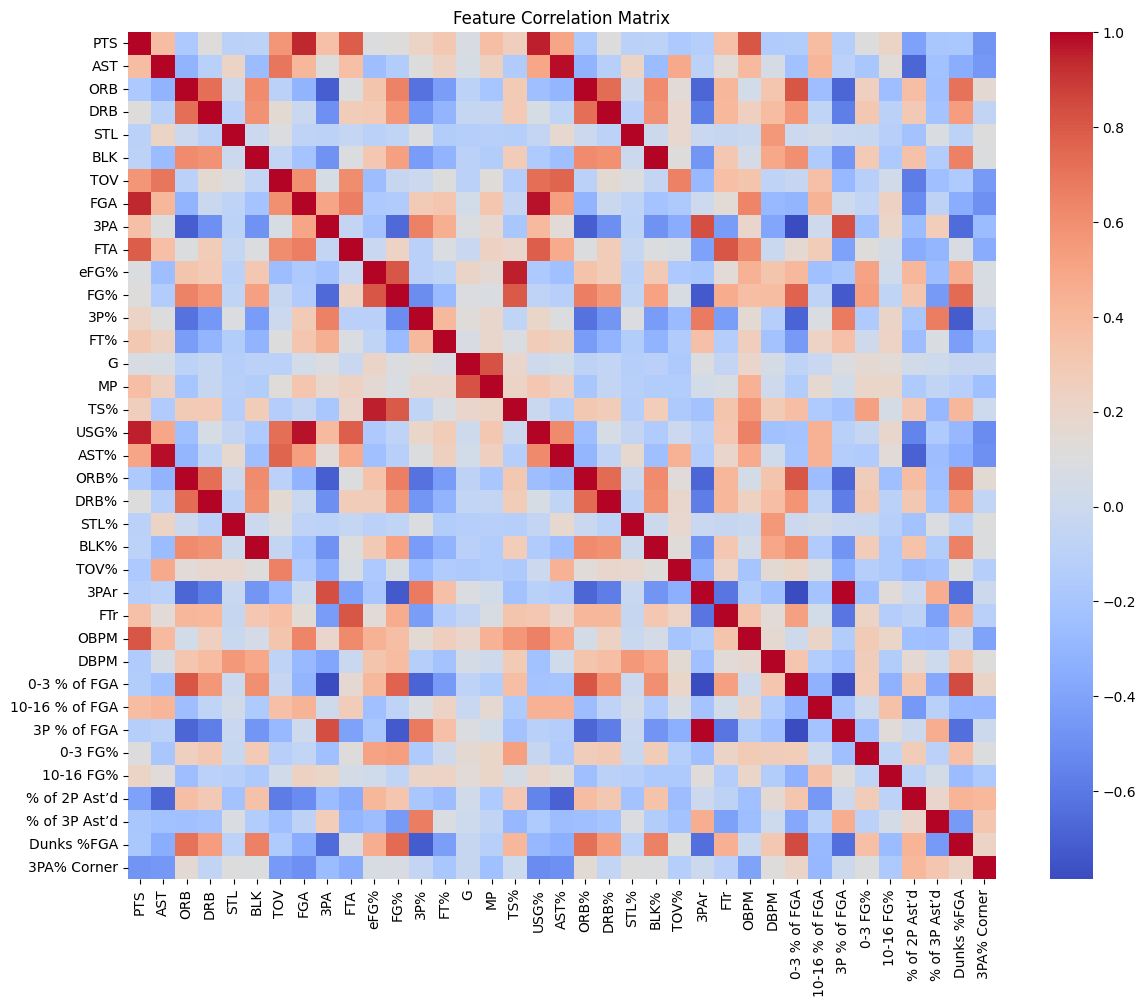

In [35]:
corr_matrix = data.corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

These features came from trial and error of sillehoute scores and analysis of the above correlation matrix.

In [53]:
selected_features = [
    "PTS",
    "USG%", "AST", "ORB", "DRB", "STL", "BLK",
    'TOV%', "0-3 % of FGA", "% of 3P Ast’d",
]

## K-means

In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.drop(["G", "MP"], axis=1).values)

data_scaled = pd.DataFrame(X_scaled, index=data.index, columns= data.drop(["G", "MP"], axis=1).columns)

I used the below setup to test different features and decide which were worth keeping

In [55]:
X_cluster = data_scaled[selected_features]

kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(X_cluster)

print(silhouette_score(X_cluster, clusters))

data["cluster"] = clusters

0.2549624770640306


Applying PCA to the scaled data and then clustering it with K-Means

In [56]:
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_cluster)

kmeans_2d = KMeans(n_clusters=7, random_state=0)
clusters_2d = kmeans_2d.fit_predict(X_pca)

data["cluster"] = clusters_2d

Scree plot of variance for PCA components 

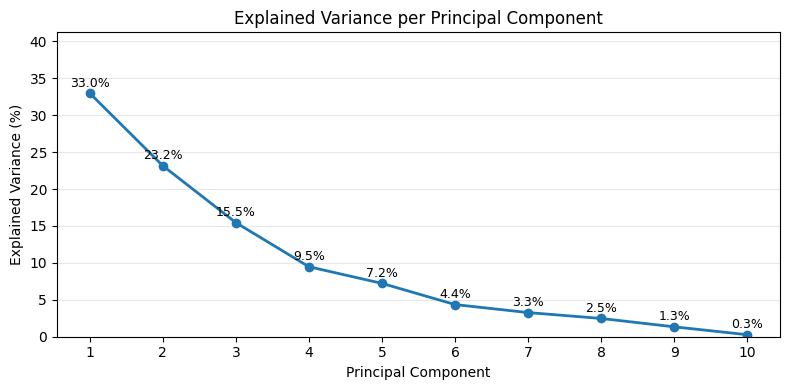

In [58]:
pca_full = PCA().fit(X_cluster)         
evr = pca_full.explained_variance_ratio_
pcs = np.arange(1, len(evr) + 1)

plt.figure(figsize=(8,4))
plt.plot(pcs, evr*100, '-o', linewidth=2, markersize=6)
for i, v in enumerate(evr*100, start=1):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Explained Variance per Principal Component')
plt.xticks(pcs)
plt.ylim(0, max(evr*100) * 1.25)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Feature importance for the 2 dimensions of PCA

<Figure size 1200x600 with 0 Axes>

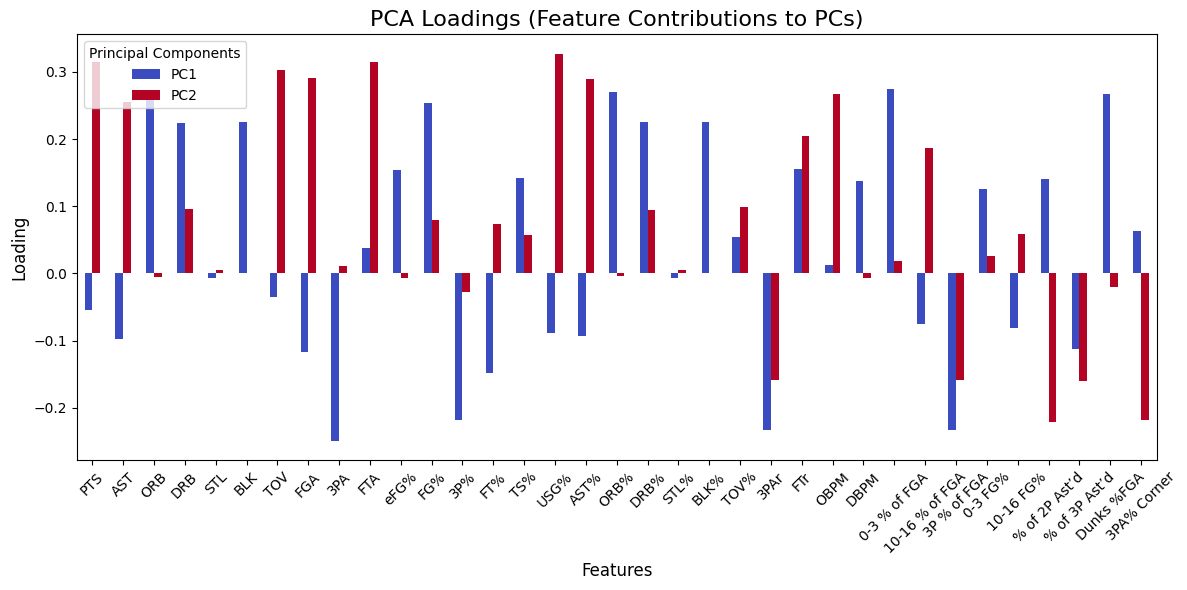

In [63]:
pca2D = PCA(n_components=2, random_state=0).fit(X_scaled)
loadings = pca2D.components_.T

loadings_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(loadings.shape[1])], index=data_scaled.columns)  # Exclude 'cluster' column

#Plot bars for the loadings of each feature on the two principal components
plt.figure(figsize=(12, 6))
loadings_df.plot(kind='bar', figsize=(12, 6), cmap="coolwarm")
plt.title("PCA Loadings (Feature Contributions to PCs)", fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Loading', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Principal Components", loc="upper left")
plt.tight_layout()
plt.show()

Graphing the clusters generated by K-Means

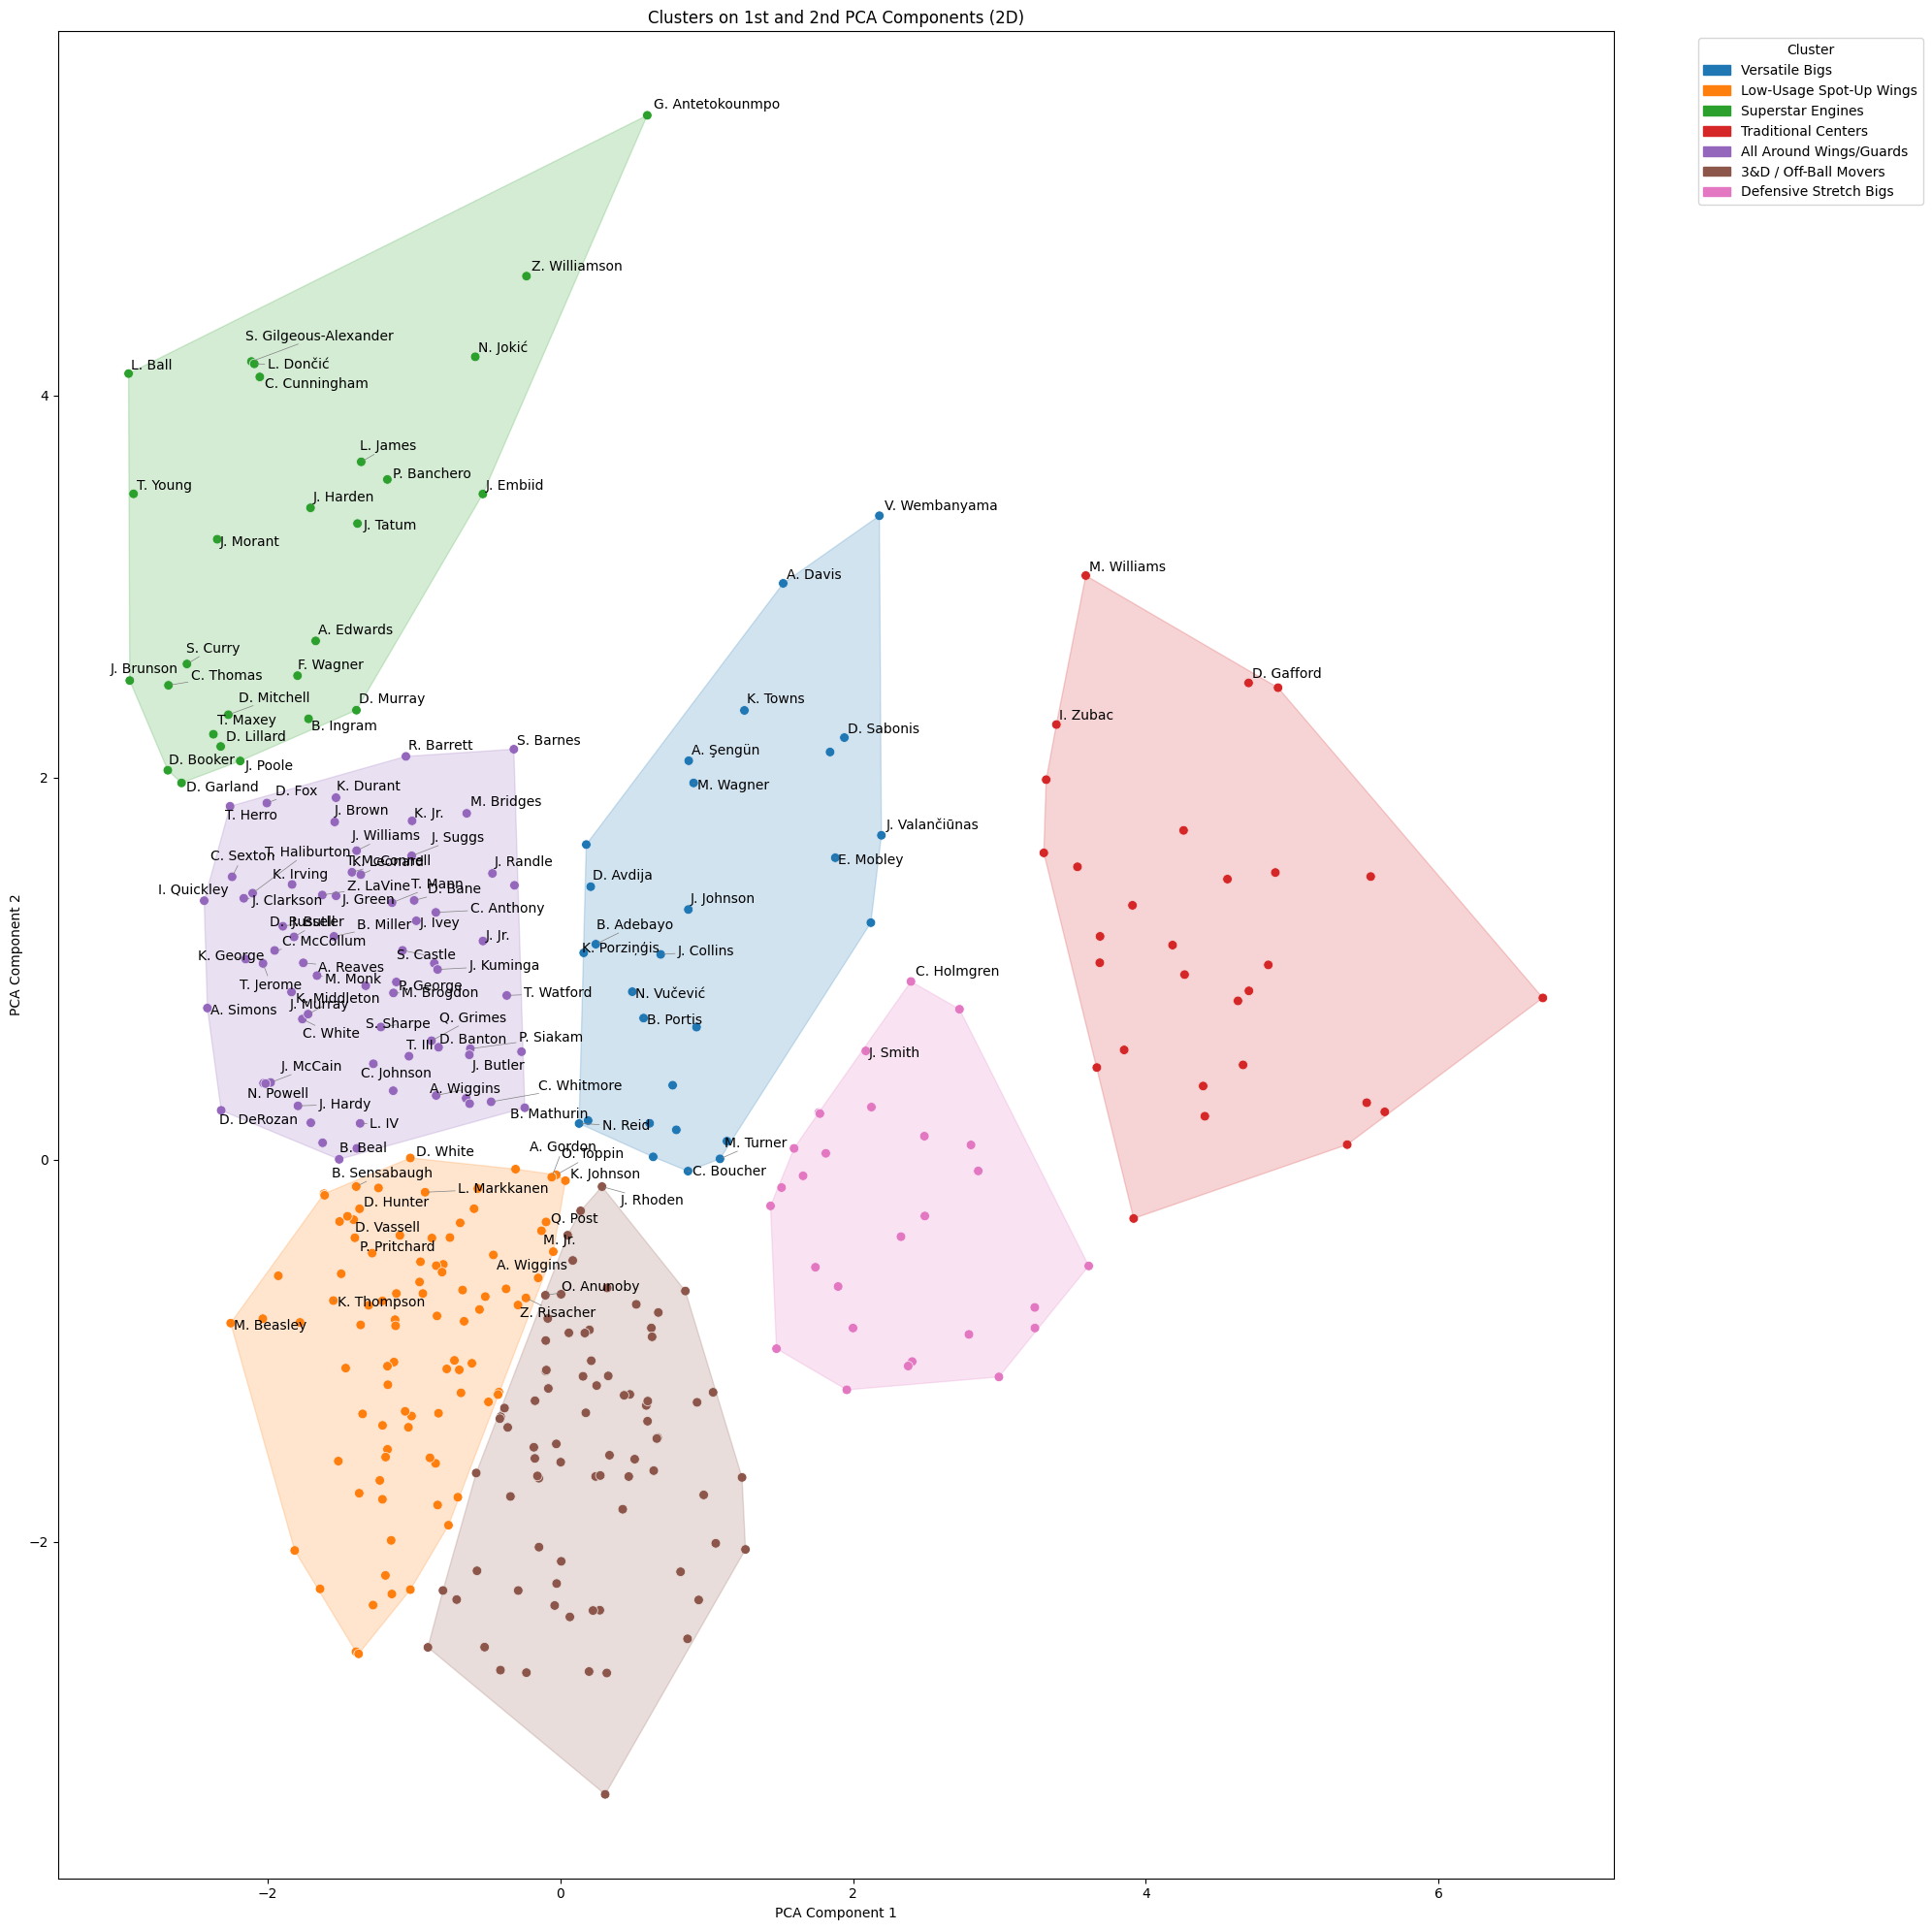

In [ ]:
plt.figure(figsize=(20, 20))
unique_clusters = np.unique(clusters_2d)
palette = sns.color_palette('tab10', n_colors=len(unique_clusters))

ax = sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_2d, palette=palette, s=50, legend=False)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clusters on 1st and 2nd PCA Components (2D)')

#Draw convex hulls for each cluster
for cluster_id in unique_clusters:
    points = X_pca[clusters_2d == cluster_id]
    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_pts = points[hull.vertices]
        polygon = plt.Polygon(hull_pts, color=palette[cluster_id], alpha=0.2)
        ax.add_patch(polygon)

#Label only top players by scoring for readability
top_players = data.sort_values("PTS", ascending=False).head(125).index
texts = []

for i, player in enumerate(data.index):
    if player in top_players:
        parts = player.split()
        if len(parts) >= 2:
            label = f"{parts[0][0]}. {parts[-1]}"
        else:
            label = player
        texts.append(ax.text(X_pca[i, 0], X_pca[i, 1], label, fontsize=10))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

#Custom Legend (made after analysis)
cluster_labels = ["Versatile Bigs", "Low-Usage Spot-Up Wings", "Superstar Engines", "Traditional Centers", "All Around Wings/Guards", "3&D / Off-Ball Movers", "Defensive Stretch Bigs"]
patches = [
    mpatches.Patch(color=palette[i], label=cluster_labels[i])  # Use custom label here
    for i in unique_clusters
]
plt.legend(handles=patches, title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Average values for each K-Means cluster

In [ ]:
data.groupby('cluster').mean().round(2)

,PTS,AST,ORB,DRB,STL,BLK,TOV,FGA,3PA,FTA,...,0-3 % of FGA,10-16 % of FGA,3P % of FGA,0-3 FG%,10-16 FG%,% of 2P Ast’d,% of 3P Ast’d,Dunks %FGA,3PA% Corner,dendro_cluster
cluster,,,,,,,,,,,,,,,,,,,,,
0,25.83,5.70,3.32,10.45,1.61,1.58,3.48,19.45,6.05,5.66,...,0.29,0.08,0.31,0.70,0.39,0.62,0.90,0.08,0.21,0.0
1,20.79,4.73,1.33,4.91,1.52,0.53,2.20,17.10,9.54,2.98,...,0.16,0.08,0.56,0.66,0.42,0.58,0.89,0.03,0.28,1.0
2,36.17,9.50,1.41,7.02,1.76,0.70,4.57,26.96,10.19,9.01,...,0.19,0.13,0.38,0.68,0.46,0.34,0.58,0.03,0.09,2.0
3,18.98,3.44,6.23,10.95,1.46,2.44,2.42,12.82,0.41,4.73,...,0.59,0.04,0.03,0.73,0.30,0.70,0.26,0.30,0.28,3.0
4,27.29,7.24,1.36,5.61,1.69,0.65,3.56,21.80,8.80,5.52,...,0.18,0.12,0.40,0.68,0.42,0.40,0.76,0.03,0.18,4.0
5,16.81,3.50,2.09,5.92,1.88,0.99,1.87,13.83,7.07,2.52,...,0.22,0.05,0.52,0.69,0.37,0.65,0.96,0.06,0.39,5.0
6,18.78,3.69,4.40,9.31,1.78,1.90,2.30,14.69,3.83,3.70,...,0.39,0.09,0.26,0.71,0.40,0.69,0.95,0.16,0.40,6.0


Players in cluster 4 (purple - Secondary Scoring Wings / Guards)

In [ ]:
data.loc[(data["cluster"] == 4)].index

Index(['DeMar DeRozan', 'Tyler Herro', 'Jalen Green', 'Austin Reaves',
       'Pascal Siakam', 'Tyrese Haliburton', 'Coby White', 'Jamal Murray',
       'Chris Paul', 'Anfernee Simons', 'Kevin Durant', 'Shaedon Sharpe',
       'Jalen Williams', 'Julius Randle', 'Jaren Jackson Jr.', 'Desmond Bane',
       'Stephon Castle', 'Jaylen Brown', 'Bennedict Mathurin',
       'Scottie Barnes', 'Keyonte George', 'Russell Westbrook', 'Malik Monk',
       'Miles Bridges', 'Norman Powell', 'RJ Barrett', 'Trey Murphy III',
       'Isaiah Collier', 'CJ McCollum', 'Kyrie Irving', 'Cameron Johnson',
       'Scoot Henderson', 'Collin Sexton', 'Bradley Beal', 'Scotty Pippen Jr.',
       'T.J. McConnell', 'Ty Jerome', 'Jose Alvarado', 'Paul George',
       'Cole Anthony', 'Kawhi Leonard', 'Jonathan Kuminga', 'Dalano Banton',
       'Cameron Payne', 'Jalen Suggs', 'Jordan Clarkson', 'Brandon Miller',
       'Immanuel Quickley', 'Trendon Watford', 'Jaden Hardy', 'Jaden Ivey',
       'Cam Whitmore', 'Jared Mc

The same K-Means graph but without labels and polygons

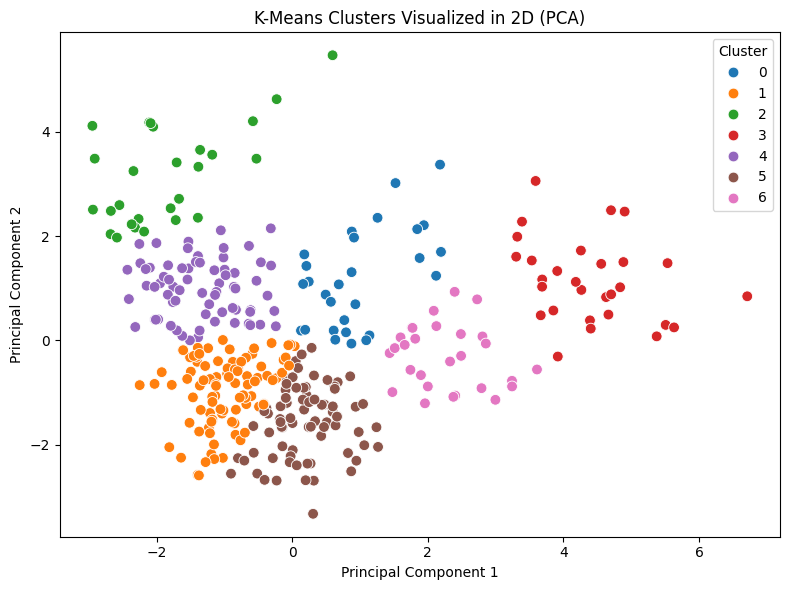

In [ ]:
df = data.copy(deep=True)

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_pca)
df['PCA1'] = X_pca_2[:, 0]
df['PCA2'] = X_pca_2[:, 1]


plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='cluster', palette='tab10', s=60)
plt.title("K-Means Clusters Visualized in 2D (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

Player distribution of different K-Means clusters - most are type 1 which makes sense (role players not superstars)

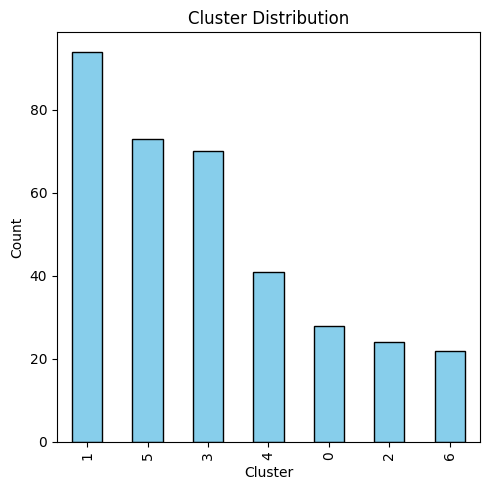

In [ ]:
cluster_counts = data['cluster'].value_counts()
plt.figure(figsize=(5, 5))
cluster_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Cluster Distribution')
plt.tight_layout()
plt.show()

## Agglomerative Clustering

The old filter had far too many players to properly display on the dendrogram so I cut the player count down further.

In [22]:
#More aggressive filter: 25 MPG and 40 Games Played
mask = ((data['MP'] / data['G']) >= 25) & (data['G'] >= 40)
removed_players = data[~mask].index.tolist()
data_dendro = data[mask].drop(["cluster"], axis=1)

print(f"Removed {len(removed_players)} players:")

Removed 192 players:


In [23]:
data_dendro.shape

(160, 37)

With the dataset much smaller, the data must be rescaled before running the AgglomerativeClustering algorithm

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_dendro.drop(["G", "MP"], axis=1).values)
data_scaled = pd.DataFrame(X_scaled, index=data_dendro.index, columns=data_dendro.drop(["G", "MP"], axis=1).columns)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(data_scaled[selected_features])

Apply scikit-learn's AgglomerativeClustering algorithm to the scaled data

In [25]:
n_clusters = 10

agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = agg_clustering.fit_predict(X_pca)
data_dendro["dendro_cluster"] = cluster_labels

Now let's plot the dendrogram to visualize these clusters and player parings

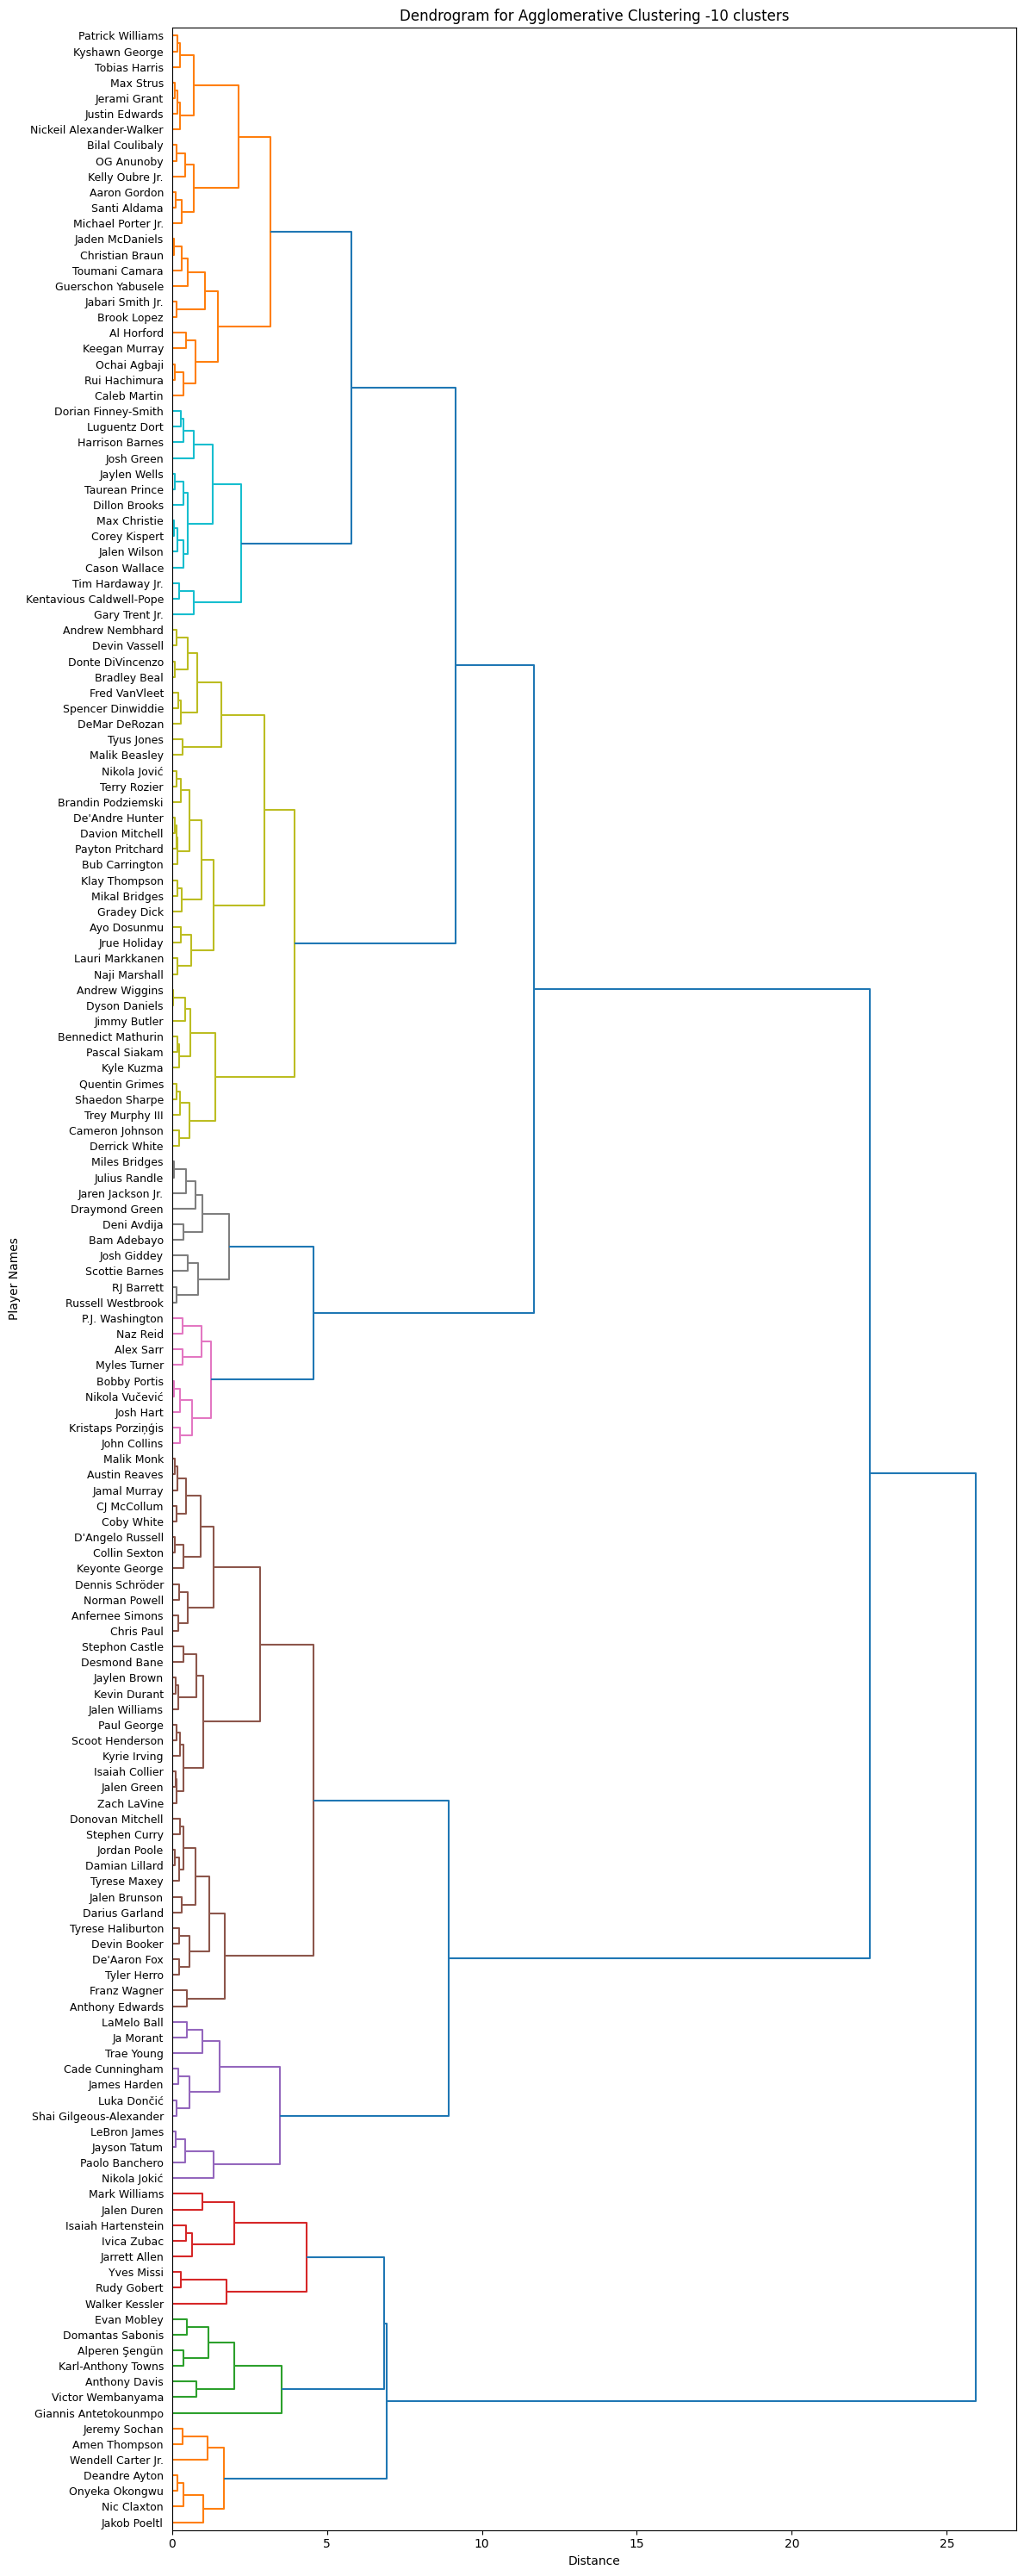

In [ ]:
linkage_matrix = sch.linkage(X_pca, method='ward')
threshold = linkage_matrix[-(n_clusters - 1), 2]

# Plot dendrogram with n_clusters colors and with player names as indexes
plt.figure(figsize=(12, 30))
sch.dendrogram(
    linkage_matrix,
    labels=data_scaled.index.tolist(),
    orientation='right',
    color_threshold=threshold,
    leaf_font_size=9
)

plt.title(f"Dendrogram for Agglomerative Clustering -{n_clusters} clusters")
plt.xlabel("Distance")
plt.ylabel("Player Names")
plt.tight_layout()
plt.show()

Averages for the dendrogram clusters (about the same patterns as the K-Means)

In [20]:
data_dendro.groupby('dendro_cluster')[selected_features].mean().round(2).sort_index()

,PTS,USG%,AST,ORB,DRB,STL,BLK,TOV%,0-3 % of FGA,% of 3P Ast’d
dendro_cluster,,,,,,,,,,
0,30.06,26.07,8.03,0.95,5.17,1.68,0.51,12.57,0.16,0.65
1,23.80,20.44,5.62,1.42,5.32,1.61,0.58,11.01,0.17,0.85
2,21.18,16.36,3.90,5.76,12.02,1.21,2.22,13.30,0.58,0.12
3,33.56,27.77,6.44,4.01,12.89,1.43,2.23,12.56,0.36,0.86
4,26.83,24.49,7.65,2.38,8.52,1.74,1.11,15.17,0.25,0.88
5,36.88,32.15,11.06,1.37,7.96,1.83,0.75,13.86,0.18,0.52
6,21.29,17.81,4.17,4.66,9.56,1.64,1.69,12.80,0.44,0.99
7,19.65,16.68,3.60,2.14,6.12,1.47,1.03,10.37,0.24,0.95
8,17.64,14.76,3.03,1.39,4.23,1.51,0.44,9.36,0.16,0.96
